sasho beshe tuk

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import scipy.stats as stats
from sklearn.metrics import classification_report

In [3]:
df = pd.read_parquet('./bird_habitats_weather.parquet')

### Sampling

In [4]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,1,380,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,2,380,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,3,380,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,4,380,-5.4,-10.5,-3.0,0.4,3.3,89.0,0.4,218.0
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,5,380,-2.3,-4.6,-1.0,0.4,3.5,92.0,0.0,177.0


In [5]:
df.describe()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
count,6.626004e+06,6.626004e+06,6626004,6.626004e+06,6.626004e+06,6.626004e+06,6.626004e+06,6.626004e+06,6.626004e+06,6.626004e+06,...,6.626004e+06,6.626004e+06,6.606095e+06,6.606095e+06,6.606095e+06,6.606095e+06,6.604528e+06,6.606095e+06,6.604580e+06,6.604580e+06
mean,5.169925e+01,5.158856e+00,2017-12-31 02:36:07.731140,9.513145e+00,4.916683e+00,6.019480e-02,8.878132e+00,2.963446e+00,9.127970e-01,1.960811e+00,...,1.831251e+02,3.242213e+02,1.119858e+01,7.152716e+00,1.510855e+01,2.227178e+00,4.096873e+00,7.936663e+01,5.113881e+00,1.080127e+03
min,5.075000e+01,3.350000e+00,2010-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.000000e+00,2.400000e+02,-1.210000e+01,-1.890000e+01,-6.700000e+00,0.000000e+00,0.000000e+00,2.900000e+01,0.000000e+00,2.000000e+01
25%,5.145000e+01,4.500000e+00,2013-12-31 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,5.121900e+00,1.054900e+00,0.000000e+00,2.781000e-01,...,9.200000e+01,2.600000e+02,6.700000e+00,3.100000e+00,9.600000e+00,0.000000e+00,2.500000e+00,7.300000e+01,1.200000e+00,3.460000e+02
50%,5.170000e+01,5.250000e+00,2017-12-31 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,9.652400e+00,2.144400e+00,0.000000e+00,9.579000e-01,...,1.830000e+02,3.300000e+02,1.120000e+01,7.300000e+00,1.500000e+01,0.000000e+00,3.600000e+00,8.100000e+01,4.400000e+00,9.130000e+02
75%,5.200000e+01,5.850000e+00,2021-12-31 00:00:00,8.000000e+00,3.000000e+00,0.000000e+00,1.259820e+01,4.112600e+00,0.000000e+00,2.581200e+00,...,2.740000e+02,3.800000e+02,1.610000e+01,1.170000e+01,2.060000e+01,2.400000e+00,5.100000e+00,8.700000e+01,8.300000e+00,1.694000e+03
max,5.225000e+01,7.050000e+00,2025-12-31 00:00:00,1.000400e+05,2.174000e+03,5.600000e+01,1.810460e+01,1.435380e+01,1.934870e+01,1.699850e+01,...,3.660000e+02,3.910000e+02,3.090000e+01,2.320000e+01,4.020000e+01,1.064000e+02,1.800000e+01,1.000000e+02,1.570000e+01,3.130000e+03
std,3.516570e-01,8.431846e-01,NaN,4.903376e+01,1.640164e+01,3.513808e-01,4.737779e+00,2.661966e+00,3.257047e+00,2.627640e+00,...,1.054387e+02,4.983152e+01,6.226292e+00,5.763919e+00,7.291208e+00,4.688690e+00,2.260937e+00,1.062321e+01,4.260322e+00,8.113661e+02


### Filtering the data based on date

In [6]:
df_filtered = df[df['eventDate'].dt.year > 2019]

In [7]:
df_filtered.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
3652,50.75,5.65,2020-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,1,380,-0.6,-3.2,2.9,0.0,1.9,99.0,2.7,318.0
3653,50.75,5.65,2020-01-02,2.0,2,0,1.7747,0.0568,0.0,0.0616,...,2,380,3.5,-0.6,7.4,0.0,4.5,89.0,1.3,178.0
3654,50.75,5.65,2020-01-03,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,3,380,7.5,3.5,9.4,4.9,5.8,92.0,0.0,71.0
3655,50.75,5.65,2020-01-04,10.0,9,1,1.7747,0.0568,0.0,0.0616,...,4,380,5.0,2.5,6.9,0.1,3.6,90.0,1.9,237.0
3656,50.75,5.65,2020-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,5,380,5.9,5.2,7.0,0.0,3.0,84.0,0.0,116.0


In [8]:
df_filtered.dtypes

decimalLatitude                     float64
decimalLongitude                    float64
eventDate                    datetime64[us]
total_observations                  float64
speciesgroup_observations             int64
Phalacrocorax carbo                   int64
agricultural                        float64
built                               float64
coast                               float64
forest                              float64
other                               float64
sand/heather                        float64
water                               float64
wetland                             float64
main_habitat                            str
month                                 int32
day_of_year                           int32
STN                                   int64
TG                                  float64
TN                                  float64
TX                                  float64
RH                                  float64
FG                              

In [9]:
df_filtered.tail(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
6625999,52.25,6.0,2022-12-31,1.0,0,0,15.655,1.7937,0.0,0.3702,...,365,260,14.0,10.4,15.9,21.2,6.6,80.0,0.0,73.0
6626000,52.25,6.0,2023-01-01,0.0,0,0,15.655,1.7937,0.0,0.3702,...,1,260,12.4,10.4,15.6,6.1,5.4,76.0,0.8,196.0
6626001,52.25,6.0,2023-01-02,0.0,0,0,15.655,1.7937,0.0,0.3702,...,2,260,8.8,4.3,12.8,3.8,3.6,89.0,0.3,149.0
6626002,52.25,6.0,2023-01-03,0.0,0,0,15.655,1.7937,0.0,0.3702,...,3,260,6.3,1.1,9.1,1.3,4.2,89.0,0.3,115.0
6626003,52.25,6.0,2023-01-04,1.0,0,0,15.655,1.7937,0.0,0.3702,...,4,260,11.6,8.5,12.8,12.5,7.6,86.0,0.0,108.0


### Creating the seen column

In [9]:
# df_filtered['sasho'] = pd.to_numeric(pd.to_datetime(df_filtered['eventDate']))
# df_filtered['sasho1'] = pd.to_numeric(pd.to_datetime(df_filtered['date']))

In [10]:
df_filtered['seen'] = (df_filtered['Phalacrocorax carbo'] > 0).astype(int)

### Splitting the data

In [11]:
X = df_filtered.drop(columns=['Phalacrocorax carbo','seen'])

y = df_filtered['seen']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [12]:
X_train.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,agricultural,built,coast,forest,other,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
3919840,51.85,4.20,2021-12-09,0.0,0,9.0710,3.8403,0.0,0.5345,2.0071,...,343,330,5.0,3.6,6.5,1.6,7.5,92.0,0.0,139.0
4335885,51.90,5.15,2025-01-03,0.0,0,13.7677,1.2605,0.0,2.0243,1.6034,...,3,260,2.2,0.1,4.1,3.8,3.1,87.0,1.3,156.0
6071624,52.15,6.60,2025-03-15,31.0,30,13.4796,1.2914,0.0,2.5845,0.8089,...,74,290,2.6,-1.9,8.1,0.0,4.0,75.0,5.3,989.0
155938,50.85,6.05,2020-12-08,1.0,0,1.6777,5.9606,0.0,1.7072,1.9010,...,343,380,1.4,-1.1,4.0,0.0,1.8,90.0,0.7,223.0
5748384,52.10,6.45,2020-03-21,7.0,7,14.4910,0.9939,0.0,2.3083,0.7459,...,81,290,3.9,-0.9,8.7,0.0,5.5,62.0,9.9,1478.0


In [34]:
X_train.dtypes

decimalLatitude                     float64
decimalLongitude                    float64
eventDate                    datetime64[us]
total_observations                  float64
speciesgroup_observations             int64
agricultural                        float64
built                               float64
coast                               float64
forest                              float64
other                               float64
sand/heather                        float64
water                               float64
wetland                             float64
main_habitat                            str
month                                 int32
day_of_year                           int32
STN                                   int64
TG                                  float64
TN                                  float64
TX                                  float64
RH                                  float64
FG                                  float64
UG                              

In [37]:
y_train.head(5)

3919840    0
4335885    0
6071624    0
155938     0
5748384    0
Name: seen, dtype: int64

### Baseline model

In [28]:
from sklearn.ensemble import RandomForestClassifier

baseModel = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    max_depth=15
)

X_train_numeric = X_train.drop(columns=['eventDate', 'main_habitat'], errors='ignore')
X_test_numeric = X_test.drop(columns=['eventDate', 'main_habitat'], errors='ignore')

baseModel.fit(X_train_numeric, y_train)
print(baseModel.predict(X_test_numeric))

[1 0 0 ... 0 0 0]


In [19]:
import sklearn.metrics as skm
from sklearn.metrics import roc_curve, auc

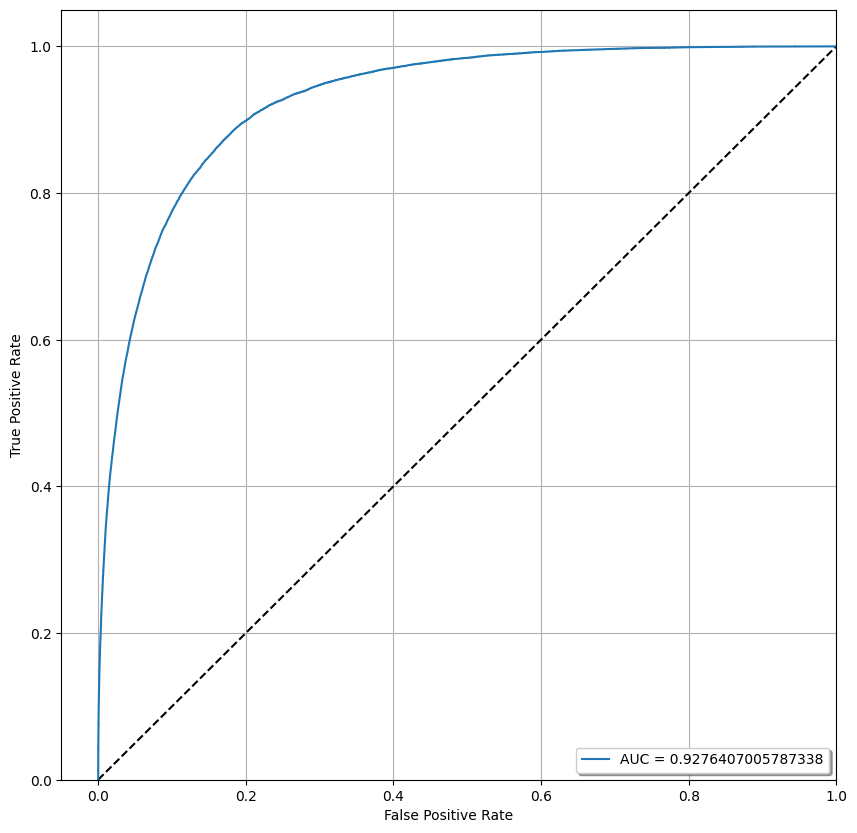

In [32]:
acc = baseModel.score(X_test_numeric,y_test)

Y_score = baseModel.predict_proba(X_test_numeric)[:,1]
fpr = dict()
tpr = dict()
fpr, tpr, sasho  = roc_curve(y_test, Y_score)

roc_auc = dict()
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,10))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.plot(fpr, tpr, label='AUC = {0}'.format(roc_auc))
plt.legend(loc="lower right", shadow=True, fancybox =True) 
plt.show()

In [31]:
print(acc)

0.9493105641058665
